In [1]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df["average"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
df["result"] = (df["average"] >= 40).astype(int)   # 1 = Pass, 0 = Fail

print(df.shape)
print(df["result"].value_counts())
df.head()

(1000, 10)
result
1    970
0     30
Name: count, dtype: int64


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average,result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = pd.get_dummies(
    df.drop(columns=["average", "result"]),
    columns=["gender", "race/ethnicity", "parental level of education",
             "lunch", "test preparation course"],
    drop_first=True,
)
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 800 | Test size: 200


Accuracy : 0.995
Precision: 1.0
Recall   : 0.9948453608247423
F1-score : 0.9974160206718347


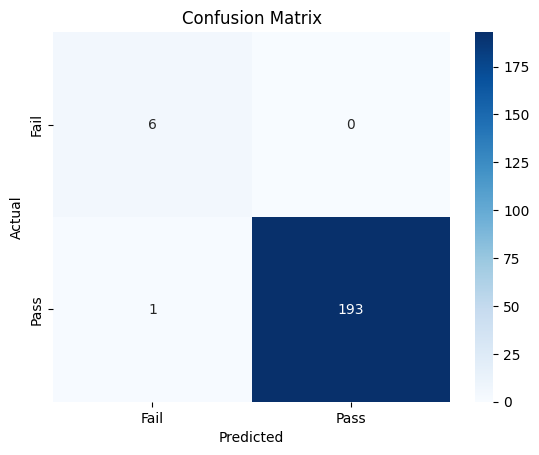

In [4]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
import joblib

joblib.dump({"model": model, "columns": list(X.columns)}, "student_model.pkl")
print("Saved student_model.pkl")

Saved student_model.pkl
